In [1]:
import pandas as pd

# Path to your Excel file
file_path = r"C:\Users\sjs93\OneDrive\Desktop\3chamber_SP_ECG_cohort1.xlsx"

# Load sheets into separate DataFrames
df_baseline = pd.read_excel(file_path, sheet_name="BL")
df_social = pd.read_excel(file_path, sheet_name="Social Preference")

# Quick look
print("Baseline data preview:")
print(df_baseline.head())

print("\nSocial Preference data preview:")
print(df_social.head())


Baseline data preview:
   Test  Animal  Left ROI : time investigating (s)  \
0    89     1.2                               87.6   
1    90     3.5                               58.2   
2    91     3.6                               55.4   
3    92     4.7                               39.2   
4    93     4.8                               45.3   

   Right ROI : time investigating (s)  Whole-Chamber : time (s)  \
0                               131.5                       300   
1                               173.7                       300   
2                                53.6                       300   
3                               118.4                       300   
4                                87.2                       300   

   Whole Chamber left : time (s)  Whole Chamber right : time (s) Sex RB side   
0                          168.7                            84.5   M     left  
1                          102.9                           183.5   M    right  
2        

Notebook Entry: Baseline Side Bias Calculation and Normalization of Social Preference Data

In order to control for innate side preferences during the social choice test, we first calculated a baseline side bias index for each mouse using the baseline recording data. The side bias index was computed as:

Side Bias Index
=
Time on Left Side
−
Time on Right Side/
Time on Left Side
+
Time on Right Side

​
 
Values near +1 indicate strong preference for the left side, near -1 indicate strong preference for the right side, and values near 0 indicate no side bias.

No animals exceeded the threshold for extreme bias (absolute value > 0.8), so all were retained for further analysis.

Next, to account for baseline side biases when analyzing social preference behavior, we normalized the investigation times during the social preference test by each animal’s corresponding baseline side time. Specifically, time investigating the Juvenile stimulus was divided by the baseline time spent on that stimulus’s side, and similarly for the Retired Breeder stimulus.

This normalization procedure adjusts for natural side biases, allowing for a more accurate assessment of true social preferences. The normalized data will be used in subsequent statistical analyses and plotting to compare investigation times toward Juvenile and Retired Breeder stimuli.

In [2]:
import numpy as np

# Assuming these are your relevant columns — update if different:
# For Baseline (BL) tab:
left_col_baseline = "Whole Chamber left : time (s)"
right_col_baseline = "Whole Chamber right : time (s)"

# For Social Preference tab:
left_col_social = "Juvenile WC : time (s)"
right_col_social = "Retired breeder WC : time (s)"

# Calculate baseline side bias index per animal
df_baseline["Side_Bias_Index"] = (
    df_baseline[left_col_baseline] - df_baseline[right_col_baseline]
) / (df_baseline[left_col_baseline] + df_baseline[right_col_baseline])

# Flag animals with extreme bias (absolute bias > 0.8)
bias_threshold = 0.8
df_baseline["Extreme_Bias"] = df_baseline["Side_Bias_Index"].abs() > bias_threshold

print("Animals with extreme baseline side bias:")
print(df_baseline.loc[df_baseline["Extreme_Bias"], ["Animal", "Side_Bias_Index"]])

# Merge baseline bias info into social preference data
df_social = df_social.merge(
    df_baseline[["Animal", "Side_Bias_Index", "Extreme_Bias"]],
    on="Animal",
    how="left"
)

# Normalize social preference times by baseline times per side
df_social["Norm_Juvenile_Time"] = df_social[left_col_social] / df_baseline.set_index("Animal").loc[df_social["Animal"], left_col_baseline].values
df_social["Norm_RB_Time"] = df_social[right_col_social] / df_baseline.set_index("Animal").loc[df_social["Animal"], right_col_baseline].values

print("\nNormalized social preference times (first few rows):")
print(df_social[["Animal", "Norm_Juvenile_Time", "Norm_RB_Time"]].head())


Animals with extreme baseline side bias:
Empty DataFrame
Columns: [Animal, Side_Bias_Index]
Index: []

Normalized social preference times (first few rows):
   Animal  Norm_Juvenile_Time  Norm_RB_Time
0     1.2            1.320095      0.347929
1     3.5            1.008746      1.048501
2     3.6            1.543779      1.232919
3     4.7            2.031297      0.841173
4     4.8            2.449886      0.506349


In [ ]:
df_social

In [3]:
print(f"Total animals in baseline data: {df_baseline['Animal'].nunique()}")
print(f"Total animals in social preference data: {df_social['Animal'].nunique()}")
print(f"Total rows in social data: {len(df_social)}")


Total animals in baseline data: 9
Total animals in social preference data: 9
Total rows in social data: 9


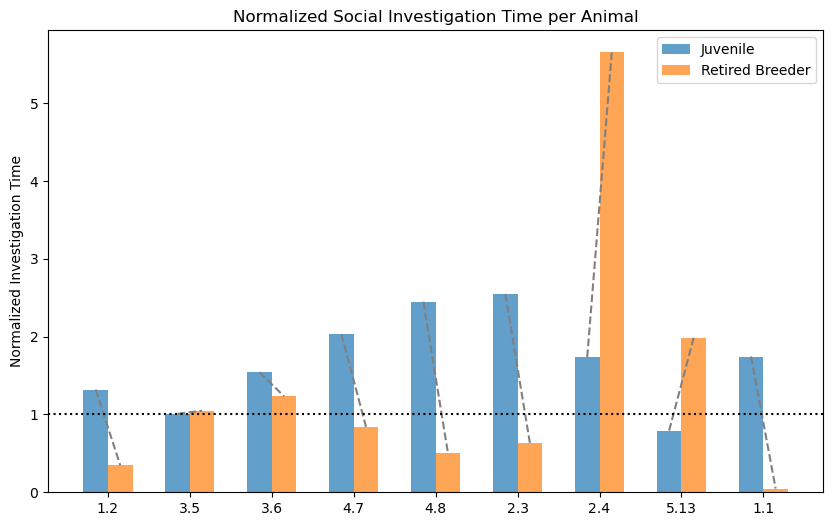

In [4]:
import matplotlib.pyplot as plt
import numpy as np

animals = df_social["Animal"]
norm_juv = df_social["Norm_Juvenile_Time"]
norm_rb = df_social["Norm_RB_Time"]

x = np.arange(len(animals))

plt.figure(figsize=(10,6))

# Bars for group means
plt.bar(x - 0.15, norm_juv, width=0.3, label="Juvenile", alpha=0.7)
plt.bar(x + 0.15, norm_rb, width=0.3, label="Retired Breeder", alpha=0.7)

# Lines connecting pairs for each animal
for i in range(len(animals)):
    plt.plot([x[i] - 0.15, x[i] + 0.15], [norm_juv.iloc[i], norm_rb.iloc[i]], color='gray', linestyle='--')

plt.xticks(x, animals)
plt.ylabel("Normalized Investigation Time")
plt.title("Normalized Social Investigation Time per Animal")
plt.legend()
plt.axhline(1, color='black', linestyle='dotted')  # Baseline normalization line
plt.show()


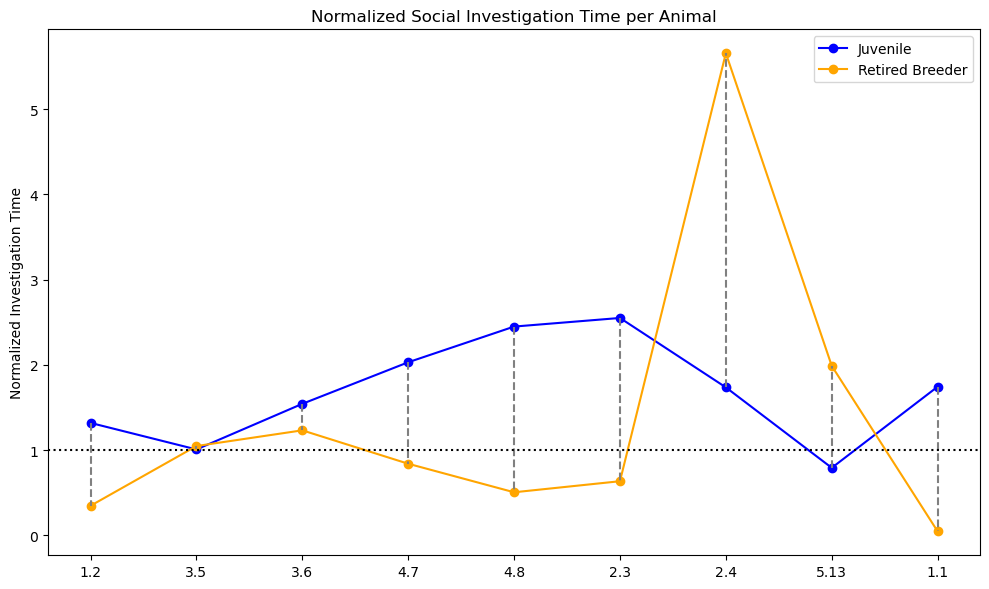

In [6]:
import matplotlib.pyplot as plt
import numpy as np

animals = df_social["Animal"].astype(str)
norm_juv = df_social["Norm_Juvenile_Time"]
norm_rb = df_social["Norm_RB_Time"]

x = np.arange(len(animals))

plt.figure(figsize=(10,6))

# Plot lines for Juvenile and Retired Breeder across animals
plt.plot(x, norm_juv, marker='o', label="Juvenile", color='blue')
plt.plot(x, norm_rb, marker='o', label="Retired Breeder", color='orange')

# Connect paired points for each animal with a dashed gray line
for i in range(len(animals)):
    plt.plot([x[i], x[i]], [norm_juv.iloc[i], norm_rb.iloc[i]], color='gray', linestyle='--')

plt.xticks(x, animals)
plt.ylabel("Normalized Investigation Time")
plt.title("Normalized Social Investigation Time per Animal")
plt.legend()
plt.axhline(1, color='black', linestyle='dotted')  # Baseline normalization line
plt.tight_layout()
plt.show()


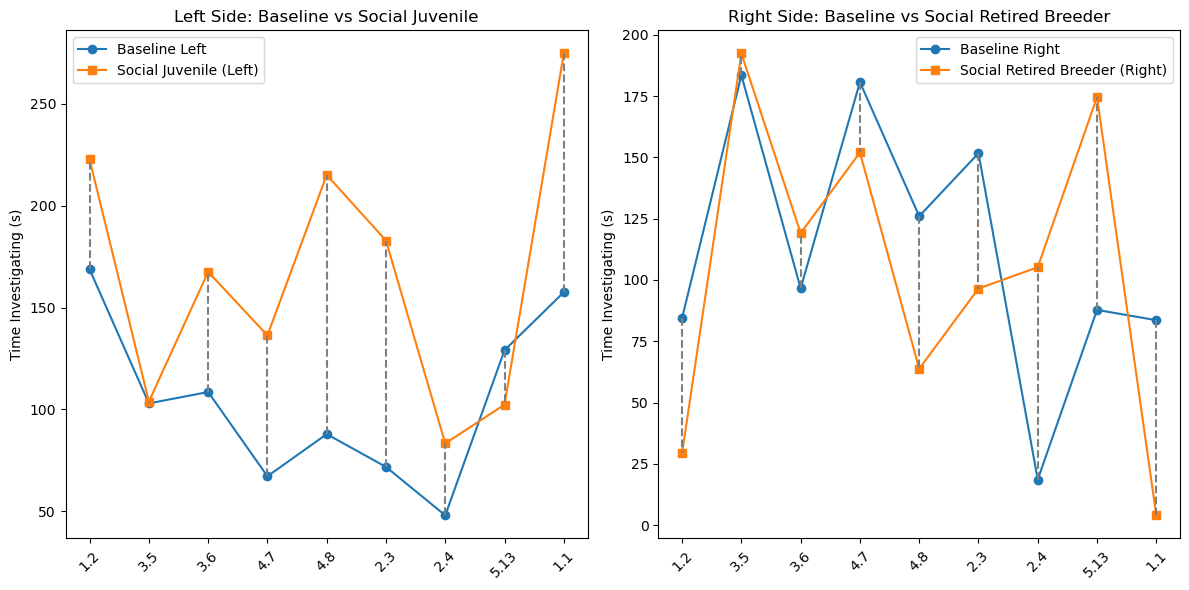

In [7]:
import matplotlib.pyplot as plt
import numpy as np

animals = df_social["Animal"].astype(str)

# Get baseline times indexed by Animal for left and right
baseline_left = df_baseline.set_index("Animal")[left_col_baseline].reindex(df_social["Animal"]).values
baseline_right = df_baseline.set_index("Animal")[right_col_baseline].reindex(df_social["Animal"]).values

# Social times (juvenile = left, RB = right)
social_left = df_social[left_col_social].values
social_right = df_social[right_col_social].values

x = np.arange(len(animals))

plt.figure(figsize=(12,6))

# Left side: baseline vs social
plt.subplot(1, 2, 1)
plt.plot(x, baseline_left, 'o-', label="Baseline Left")
plt.plot(x, social_left, 's-', label="Social Juvenile (Left)")
for i in range(len(animals)):
    plt.plot([x[i], x[i]], [baseline_left[i], social_left[i]], 'gray', linestyle='--')
plt.xticks(x, animals, rotation=45)
plt.ylabel("Time Investigating (s)")
plt.title("Left Side: Baseline vs Social Juvenile")
plt.legend()

# Right side: baseline vs social
plt.subplot(1, 2, 2)
plt.plot(x, baseline_right, 'o-', label="Baseline Right")
plt.plot(x, social_right, 's-', label="Social Retired Breeder (Right)")
for i in range(len(animals)):
    plt.plot([x[i], x[i]], [baseline_right[i], social_right[i]], 'gray', linestyle='--')
plt.xticks(x, animals, rotation=45)
plt.ylabel("Time Investigating (s)")
plt.title("Right Side: Baseline vs Social Retired Breeder")
plt.legend()

plt.tight_layout()
plt.show()
